In [10]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import LeaveOneOut, train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Load your data (assuming it's saved as a file or in variable)
# For demonstration, let's parse the data you provided

def parse_keroml_data(file_path=None, data_string=None):
    """Parse the KeroML dataset from file or string"""
    if file_path:
        with open(file_path, 'r') as f:
            lines = f.readlines()
    else:
        lines = data_string.split('\n')
    
    # Find where data starts (after # Data line)
    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data'):
            data_start = i + 2  # Skip the header line after # Data
            break
    
    if data_start is None:
        raise ValueError("Could not find data section")
    
    # Read header
    header_line = lines[data_start].strip()
    headers = header_line.split('\t')
    
    # Read data
    data_rows = []
    for line in lines[data_start + 1:]:
        if line.strip() and not line.startswith('#'):
            parts = line.strip().split('\t')
            if len(parts) == len(headers):
                data_rows.append(parts)
    
    df = pd.DataFrame(data_rows, columns=headers)
    
    # Convert numeric columns (except first few string columns)
    for col in df.columns:
        if col not in ['keroml_id', 'mixture_id', 'mixture_name']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Since your data is in the message, I'll assume you've saved it
df = parse_keroml_data('keroml_dataset.dat')

In [11]:
# %%
# Check which samples actually have cetane numbers
cetane_col = 'cetane_number_val'
print(f"Total samples: {len(df)}")
print(f"Samples with cetane value: {df[cetane_col].notna().sum()}")
print(f"Samples without cetane value: {df[cetane_col].isna().sum()}")
print(f"Percentage missing: {df[cetane_col].isna().mean()*100:.1f}%")

# Show the samples that HAVE cetane numbers
df_with_cetane = df[df[cetane_col].notna()].copy()
print(f"\nSamples with cetane values:")
print(df_with_cetane[['keroml_id', 'mixture_name', cetane_col]].to_string())

Total samples: 240
Samples with cetane value: 22
Samples without cetane value: 218
Percentage missing: 90.8%

Samples with cetane values:
               keroml_id               mixture_name  cetane_number_val
55   KERO_TRDS_A0_000055          POSF 10264 (JP-8)              48.80
56   KERO_TRDS_A0_000056         POSF 10325 (Jet A)              48.30
57   KERO_TRDS_A0_000057          POSF 10289 (JP-5)              39.20
61   KERO_TRDS_A0_000061              POSF 12223 ()              50.40
64   KERO_TRDS_A0_000064                 POSF 12345              39.60
74   KERO_TRDS_A0_000074                  POSF 4658              45.30
75   KERO_TRDS_A0_000075                  POSF 5699              49.30
76   KERO_TRDS_A0_000076                  POSF 6169              47.30
77   KERO_TRDS_A0_000077                  POSF 4751              45.90
85   KERO_TRDS_A0_000085      POSF 11714 (SPK-HEFA)              59.77
86   KERO_TRDS_A0_000086         POSF 7629 (SPK-FT)              31.30
94   KERO_

In [12]:
# %%
# Identify 2DGC feature columns
two_dgc_cols = [col for col in df.columns if col.startswith('2dgc_')]
print(f"Found {len(two_dgc_cols)} 2DGC columns")

# Create feature matrix with only 2DGC columns
X_all = df[two_dgc_cols].copy()
y_all = df[cetane_col].copy()

# Keep only rows where we have cetane values for training
train_mask = y_all.notna()
X_train = X_all[train_mask].copy()
y_train = y_all[train_mask].copy()

print(f"Training samples: {len(X_train)}")
print(f"Features: {X_train.shape[1]}")

Found 209 2DGC columns
Training samples: 22
Features: 209


In [13]:
# %%
# Approach: Use KNN to impute missing cetane values based on 2DGC similarity
# Then use ALL samples for training (with imputed targets)

from sklearn.impute import KNNImputer

# Scale features first
scaler_imp = StandardScaler()
X_scaled_imp = scaler_imp.fit_transform(X_all)

# KNN imputer for the target column (cetane)
# This estimates missing cetane values based on feature similarity
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
y_imputed = knn_imputer.fit_transform(np.column_stack([X_scaled_imp, y_all.values]))[:, -1]

print(f"Original cetane values: {y_all.notna().sum()} non-NaN")
print(f"After KNN imputation: {pd.Series(y_imputed).notna().sum()} non-NaN")

# Now use ALL samples for training
X_train_full = X_all.copy()
y_train_full = y_imputed.copy()

Original cetane values: 22 non-NaN
After KNN imputation: 240 non-NaN


In [14]:
# %%
# Clean approach: Only use samples with known cetane numbers
# This is the most trustworthy but loses data

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# FIRST: Handle the NaN values in X_train
print(f"Original X_train shape: {X_train.shape}")
print(f"NaN values in X_train: {X_train.isna().sum().sum()}")

# Option 1: Fill NaN with 0 (most appropriate for 2DGC data where NaN likely means zero)
X_train_filled = X_train.fillna(0)

# Option 2: Or use median imputation (uncomment if preferred)
# imputer = SimpleImputer(strategy='median')
# X_train_filled = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

print(f"After filling NaN: {X_train_filled.isna().sum().sum()} NaN remaining")

# Remove zero-variance and near-constant columns
X_train_clean = X_train_filled.loc[:, X_train_filled.var() > 1e-6]
X_train_clean = X_train_clean.loc[:, X_train_clean.std() > 1e-4]

print(f"After variance filtering: {X_train_clean.shape[1]} features")

# Feature selection - using f_regression (works with filled data)
selector = SelectKBest(score_func=f_regression, k=min(30, X_train_clean.shape[1]))
X_train_selected = selector.fit_transform(X_train_clean, y_train)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X_train_clean.columns[selected_mask].tolist()
print(f"Selected {len(selected_features)} features")

# Use Leave-One-Out cross-validation on the limited samples
loo = LeaveOneOut()
loo_preds = np.zeros(len(y_train))

for train_idx, test_idx in loo.split(X_train_selected):
    model = Ridge(alpha=1.0)
    model.fit(X_train_selected[train_idx], y_train.iloc[train_idx])
    loo_preds[test_idx] = model.predict(X_train_selected[test_idx].reshape(1, -1))

# Evaluate
mae = mean_absolute_error(y_train, loo_preds)
r2 = r2_score(y_train, loo_preds)
print(f"\nLOO-CV on {len(y_train)} samples:")
print(f"MAE = {mae:.3f}")
print(f"R² = {r2:.3f}")

Original X_train shape: (22, 209)
NaN values in X_train: 4
After filling NaN: 0 NaN remaining
After variance filtering: 86 features
Selected 30 features

LOO-CV on 22 samples:
MAE = 7.245
R² = 0.325


In [15]:
# %%
# After training on known samples, predict for all samples
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Train final model on all known samples
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, 
                                 min_samples_split=3, random_state=42)
rf_model.fit(X_train_selected, y_train)

# IMPORTANT: Handle X_all the SAME way we handled X_train
# First, get the 2DGC columns
two_dgc_cols = [col for col in df.columns if col.startswith('2dgc_')]
X_all_raw = df[two_dgc_cols].copy()

# Fill NaN with 0 (same method used for training)
X_all_filled = X_all_raw.fillna(0)

# Remove zero-variance columns (must match training columns)
# Get the columns that were used in training (after variance filtering)
# We need to find which columns from X_all_filled are in X_train_clean columns
common_cols = [col for col in X_train_clean.columns if col in X_all_filled.columns]
X_all_filtered = X_all_filled[common_cols]

print(f"Common columns between training and all data: {len(common_cols)}")
print(f"X_all shape after filtering: {X_all_filtered.shape}")

# Now transform using the selector (fitted on X_train_clean)
X_all_selected = selector.transform(X_all_filtered)
y_pred_all = rf_model.predict(X_all_selected)

# Add predictions to dataframe
df['cetane_predicted'] = np.nan
df.loc[train_mask, 'cetane_predicted'] = y_train  # keep actual where known
df.loc[~train_mask, 'cetane_predicted'] = y_pred_all[~train_mask]

print(f"\nPredictions made for {len(y_pred_all)} total samples")
print(f"  - Known (actual): {train_mask.sum()}")
print(f"  - Predicted: {(~train_mask).sum()}")

# Show predictions for samples without cetane
missing_mask = ~train_mask
print(f"\nPredicted cetane numbers for samples without measured values (first 10):")
for i in np.where(missing_mask)[0][:10]:  # first 10
    mixture_name = df.iloc[i]['mixture_name'] if 'mixture_name' in df.columns else f"Sample {i}"
    print(f"  {mixture_name:<35} → {y_pred_all[i]:.2f}")

Common columns between training and all data: 86
X_all shape after filtering: (240, 86)

Predictions made for 240 total samples
  - Known (actual): 22
  - Predicted: 218

Predicted cetane numbers for samples without measured values (first 10):
  POSF 3895 (JP-8)                    → 48.25
  POSF 3896 (JP-8)                    → 48.19
  POSF 3897 (JP-8)                    → 48.61
  POSF 3898 (JP-8)                    → 47.51
  POSF 3899 (JET A)                   → 46.35
  POSF 3900 (JP-8)                    → 48.73
  POSF 3901 (JET A)                   → 47.43
  POSF 3902 (JP-8)                    → 48.62
  POSF 3938 (JP-8)                    → 49.14
  POSF 3939 (JP-5)                    → 45.20


In [16]:
# %%
# Bootstrap to get uncertainty estimates for predictions
from sklearn.utils import resample

n_bootstrap = 100
bootstrap_preds = []

for b in range(n_bootstrap):
    # Resample training data with replacement
    idx_boot = resample(np.arange(len(y_train)), replace=True, 
                        n_samples=len(y_train), random_state=b)
    X_boot = X_train_selected[idx_boot]
    y_boot = y_train.iloc[idx_boot]
    
    # Train model
    model_boot = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=b)
    model_boot.fit(X_boot, y_boot)
    
    # Predict for all samples
    preds_boot = model_boot.predict(X_all_selected)
    bootstrap_preds.append(preds_boot)

bootstrap_preds = np.array(bootstrap_preds)
pred_mean = bootstrap_preds.mean(axis=0)
pred_std = bootstrap_preds.std(axis=0)
pred_lower = np.percentile(bootstrap_preds, 2.5, axis=0)
pred_upper = np.percentile(bootstrap_preds, 97.5, axis=0)

# Add to dataframe
df['cetane_pred_mean'] = pred_mean
df['cetane_pred_std'] = pred_std
df['cetane_pred_lower'] = pred_lower
df['cetane_pred_upper'] = pred_upper

print(f"Bootstrap complete: {n_bootstrap} iterations")
print(f"Prediction uncertainty (avg std): {pred_std.mean():.3f}")

Bootstrap complete: 100 iterations
Prediction uncertainty (avg std): 3.223


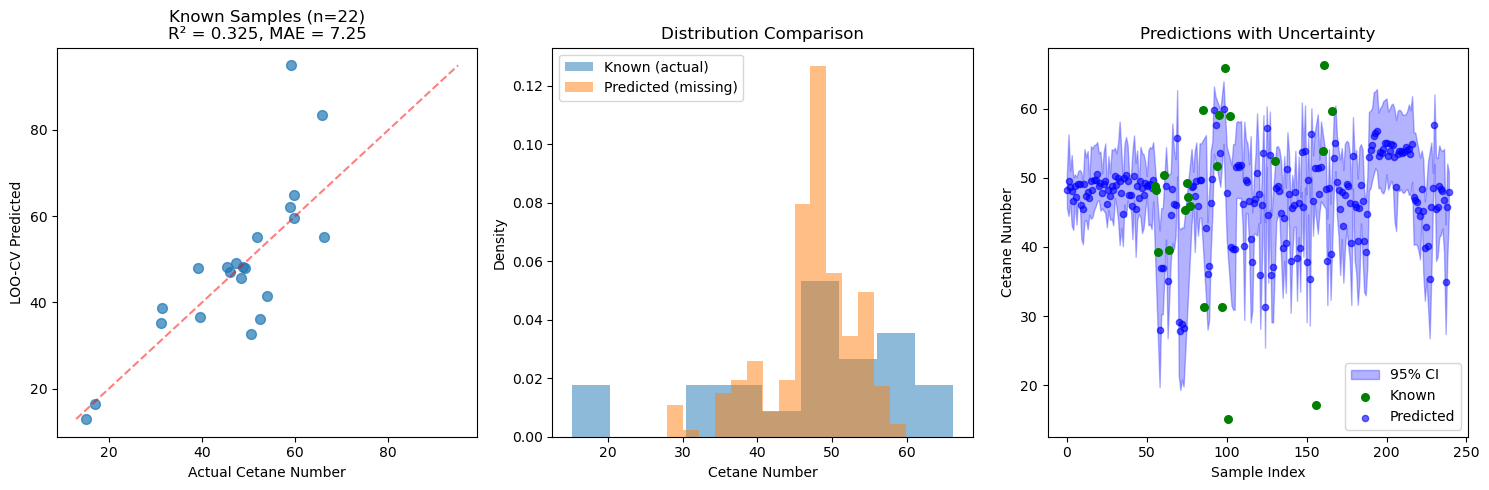

In [17]:
# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Actual vs Predicted (for known samples)
ax = axes[0]
ax.scatter(y_train, loo_preds, alpha=0.7, s=50)
min_val = min(y_train.min(), loo_preds.min())
max_val = max(y_train.max(), loo_preds.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
ax.set_xlabel('Actual Cetane Number')
ax.set_ylabel('LOO-CV Predicted')
ax.set_title(f'Known Samples (n={len(y_train)})\nR² = {r2:.3f}, MAE = {mae:.2f}')

# Plot 2: Distribution of predictions
ax = axes[1]
ax.hist(y_train, bins=10, alpha=0.5, label='Known (actual)', density=True)
ax.hist(pred_mean[~train_mask], bins=15, alpha=0.5, label='Predicted (missing)', density=True)
ax.set_xlabel('Cetane Number')
ax.set_ylabel('Density')
ax.set_title('Distribution Comparison')
ax.legend()

# Plot 3: Predictions with uncertainty
ax = axes[2]
x_plot = np.arange(len(df))
ax.fill_between(x_plot[~train_mask], pred_lower[~train_mask], pred_upper[~train_mask], 
                alpha=0.3, color='blue', label='95% CI')
ax.scatter(x_plot[train_mask], y_train, color='green', s=30, label='Known', zorder=3)
ax.scatter(x_plot[~train_mask], pred_mean[~train_mask], color='blue', s=20, alpha=0.6, 
           label='Predicted', zorder=2)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cetane Number')
ax.set_title('Predictions with Uncertainty')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('cetane_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


Top 20 Most Important 2DGC Features:
             feature  importance
11  2dgc_iso_par_c12    0.243481
1   2dgc_nor_par_c09    0.219886
3   2dgc_nor_par_c12    0.104266
10  2dgc_iso_par_c09    0.092750
2   2dgc_nor_par_c11    0.069653
5   2dgc_nor_par_c14    0.051949
13  2dgc_iso_par_c15    0.039701
0   2dgc_nor_par_c08    0.036466
12  2dgc_iso_par_c13    0.027799
14  2dgc_iso_par_c17    0.019682
16  2dgc_iso_par_c20    0.015952
18  2dgc_mon_nap_c09    0.013567
15  2dgc_iso_par_c18    0.011128
4   2dgc_nor_par_c13    0.010631
23  2dgc_mon_aro_c16    0.008566
9   2dgc_iso_par_c08    0.007541
7   2dgc_nor_par_c16    0.006970
21   2dgc_di_nap_c16    0.005144
6   2dgc_nor_par_c15    0.003428
22   2dgc_di_nap_c17    0.002544


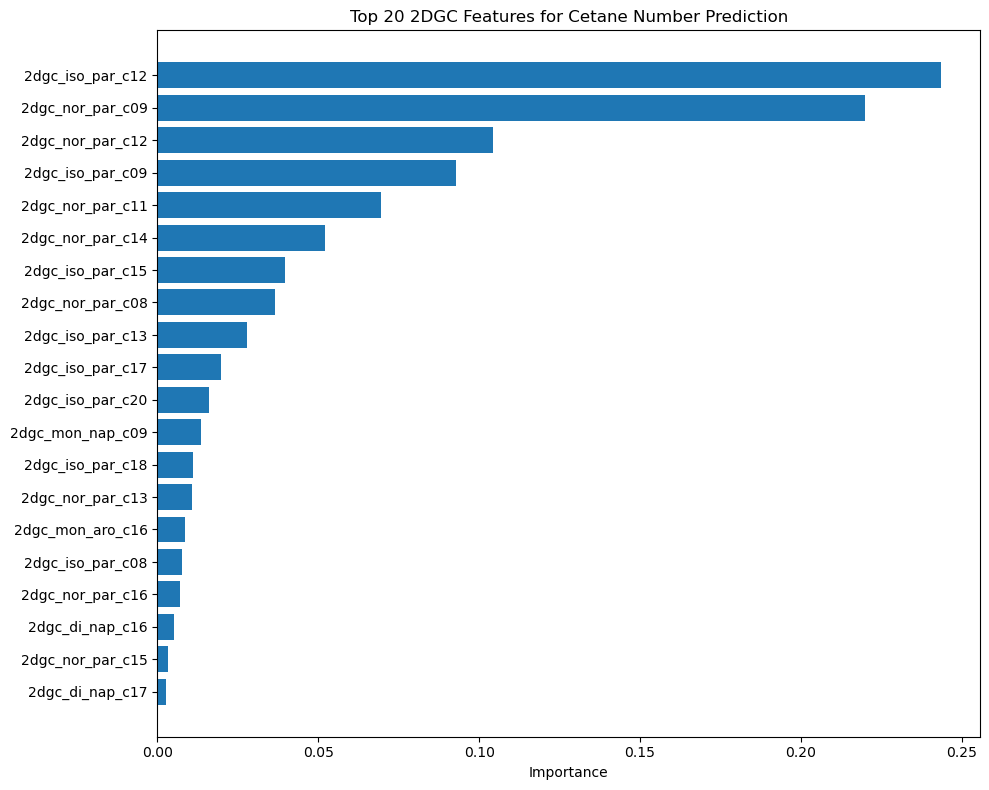

In [18]:
# %%
# Fit final model and analyze feature importance
rf_final = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_final.fit(X_train_selected, y_train)

# Feature importance
importances = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important 2DGC Features:")
print(importances.head(20).to_string())

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importances.head(20)['feature'][::-1], importances.head(20)['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 20 2DGC Features for Cetane Number Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()